# 第9章 模型设定与数据问题

## 9.4 解释变量个数的选择

可供选择的权衡标准如下：
1. 校正可决系数$\bar R^2$：择解释变量的个数K以最大化$\bar R^2$
2. 赤池信息准则(Akaike Information Criterion，简记AIC)
3. 贝叶斯信息准则(Bayesian Information Criterion，简记BIC)

在 Stata 中作完回归后，计算信息准则的命令为：
```
estat ic
```
- ic表示information criterion(信息准则)。

4. 大到小的序贯t规则(general-to-specific sequential t rule)，这种方法常用于时间序列模型：首先，设一个最大滞后期$p_{\text{max}}$，令$\hat p=p_{\text{max}}$进行估计，并对最后一阶系数的显著性进行t检验。如果接受该系数为0，则令$\hat p=p_{\text{max}}-1$，重新进行估计，再对(新的)最后一阶系数的显著性进行t检验，如果显著，则停止；否则，令$\hat p=p_{\text{max}}$-2；以此类推。

In [1]:
use data/icecream.dta,clear
quietly reg consumption temp price income
estat ic


Akaike's information criterion and Bayesian information criterion

-----------------------------------------------------------------------------
       Model |          N   ll(null)  ll(model)      df        AIC        BIC
-------------+---------------------------------------------------------------
           . |         30   39.57876   58.61944       4  -109.2389  -103.6341
-----------------------------------------------------------------------------
Note: BIC uses N = number of observations. See [R] IC note.


In [2]:
* 在以上模型中加入气温的一阶滞后项(L.temp)，重新进行估计。
qui reg consumption temp L.temp price income
estat ic


Akaike's information criterion and Bayesian information criterion

-----------------------------------------------------------------------------
       Model |          N   ll(null)  ll(model)      df        AIC        BIC
-------------+---------------------------------------------------------------
           . |         29   37.85248   63.41576       5  -116.8315   -109.995
-----------------------------------------------------------------------------
Note: BIC uses N = number of observations. See [R] IC note.


从以上结果可知，增加解释变量L.temp后，AIC与BIC都下降了。进一步，引入气温的二阶滞后项(L2.temp)：

In [3]:
qui reg consumption temp L.temp L2.temp price income
estat ic


Akaike's information criterion and Bayesian information criterion

-----------------------------------------------------------------------------
       Model |          N   ll(null)  ll(model)      df        AIC        BIC
-------------+---------------------------------------------------------------
           . |         28   36.08382   61.12451       6   -110.249  -102.2558
-----------------------------------------------------------------------------
Note: BIC uses N = number of observations. See [R] IC note.


结果显示，加入气温的二阶滞后项后，AIC与BIC反而比仅包括气温的一阶滞后项上升了。因此，仅包含气温的一阶滞后项可以达到AIC与BIC的最小值。这意味着，从信息准则的角度，应包含气温的一阶滞后项，但不该引入更高阶的气温滞后项。

其次，使用序贯t规则，并假设$p_{\text{max}}=2$，估计以下模型：

In [4]:
reg consumption temp L.temp L2.temp price income


      Source |       SS           df       MS      Number of obs   =        28
-------------+----------------------------------   F(5, 22)        =     21.92
       Model |  .103722201         5   .02074444   Prob > F        =    0.0000
    Residual |  .020822754        22  .000946489   R-squared       =    0.8328
-------------+----------------------------------   Adj R-squared   =    0.7948
       Total |  .124544954        27  .004612776   Root MSE        =    .03077

------------------------------------------------------------------------------
 consumption | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        temp |
         --. |   .0047858   .0013502     3.54   0.002     .0019856     .007586
         L1. |  -.0010836   .0022905    -0.47   0.641    -.0058338    .0036666
         L2. |  -.0008022   .0013414    -0.60   0.556    -.0035841    .0019797
             |
       price |  -.73

从上表可知，L2.temp的系数高度不显著(p值为0.556)。因此，令$\hat p=p_{\text{max}}-1=1$(即去掉L2.temp)，重新进行估计。

In [5]:
reg consumption temp L.temp price income


      Source |       SS           df       MS      Number of obs   =        29
-------------+----------------------------------   F(4, 24)        =     28.98
       Model |  .103387183         4  .025846796   Prob > F        =    0.0000
    Residual |  .021406049        24  .000891919   R-squared       =    0.8285
-------------+----------------------------------   Adj R-squared   =    0.7999
       Total |  .124793232        28  .004456901   Root MSE        =    .02987

------------------------------------------------------------------------------
 consumption | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        temp |
         --. |   .0053321   .0006704     7.95   0.000     .0039484    .0067158
         L1. |  -.0022039   .0007307    -3.02   0.006    -.0037119   -.0006959
             |
       price |  -.8383021   .6880205    -1.22   0.235    -2.258307    .5817025
      income |   .00

从上表可知，L.temp的系数在1%平上显著(p值为0.006)，故最终选择$\hat p=1$；此结果与信息准则的结果相同。

## 9.5 对函数形式的检验

Ramsey's RESET检验(Regression Equation Specification Error Test)的基本思想是，如果怀疑非线性项被遗漏，那么就把非线性项引入方程，并检验其系数是否显著。假设线性回归模型为：
$$
y=\alpha+\beta x_1+\gamma x_2+\epsilon
$$
记此回归的拟合值为：
$$
\hat y=\hat\alpha+\hat\beta x_1+\hat\gamma x_2
$$
既然$\hat y$是解释变量的线性组合，$\hat y^2$就包含了解释变量二次项(含平方项与交叉项)的信息，$\hat y^3$就包含了解释变量三次项的信息，以此类推。考虑以下辅助回归：
$$
y=\alpha+\beta x_1+\gamma x_2+\delta_2\hat y^2+\delta_3\hat y^3+\delta_4\hat y^4+\epsilon
$$
然后对$H_0:\delta_2=\delta_3=\delta_4=0$作F检验，即检验拟合值$\hat y$的高次项系数是否联合为0。如果拒绝$H_0$,说明模型中应有高次项；反之，如果接受$H_0$，则可使用线性模型。

在Stata中作完回归，进行RESET检验的命令为
```
estat ovtest,rhs
```

- ovtest表示omitted variable test(遗漏变量检验)，因为遗漏高次项的后果类似于遗漏解释变量。
- 选择项rhs表示使用解释变量的幂为非线性项，默认使用$\hat y^2,\hat y^3,\hat y^4$为非线性项。

In [6]:
* 首先，打开数据集，并进行 OLS 回归。
use data/grilic.dta,clear 
qui reg lnw s expr tenure smsa rns
* 然后，使用拟合值的高次项进行RESET检验。
estat ovtest


Ramsey RESET test for omitted variables
Omitted: Powers of fitted values of lnw

H0: Model has no omitted variables

F(3, 749) =   1.51
 Prob > F = 0.2114


上表显示，p值为0.2114,可接受原假设，未发现遗漏高次项。

In [7]:
* 下面，直接使用解释变量的高次项进行RESET检验。
estat ovtest,rhs


Ramsey RESET test for omitted variables
Omitted: Powers of independent variables

H0: Model has no omitted variables

F(9, 743) =   2.03
 Prob > F = 0.0336


上表显示，可在5%水平上拒绝原假设，即认为遗漏了高阶非线性项。

In [8]:
* 根据劳动经济学的知识，工资对数与工龄(expr)的关系可能存在非线性。为此，引入工龄的平方项，记为expr2,再进行回归。
gen expr2=expr^2
reg lnw s expr expr2 tenure smsa rns


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(6, 751)       =     69.65
       Model |  49.7985818         6  8.29976364   Prob > F        =    0.0000
    Residual |   89.487568       751   .11915788   R-squared       =    0.3575
-------------+----------------------------------   Adj R-squared   =    0.3524
       Total |   139.28615       757  .183997556   Root MSE        =    .34519

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .1029839   .0058299    17.66   0.000     .0915391    .1144287
        expr |   .0018351   .0157708     0.12   0.907    -.0291249    .0327951
       expr2 |   .0051819   .0020645     2.51   0.012      .001129    .0092348
      tenure |    .037085   .0077374     4.79   0.

上表显示，工龄平方(expr2)在1%著为正，但工龄本身(expr)却变得很不显著；这是因为二者存在多重共线性。

再次使用解释变量的高次项进行RESET检验：

In [9]:
estat ovtest,rhs

note: expr2 omitted because of collinearity.
note: expr2^2 omitted because of collinearity.

Ramsey RESET test for omitted variables
Omitted: Powers of independent variables

H0: Model has no omitted variables

F(11, 741) =   1.73
  Prob > F = 0.0626


从上表可知，可以在5%水平上，接受“无遗漏变量”的原假设。

## 9.6 多重共线性

如果在解释变量中，有某一解释变量可由其他解释变量线性表出，则存在严格多重共线性(strict multicollinearity)。

可定义解释变量$x_k$的方差膨胀因子(Variance Inflation Factor，简记VIF)为：
$$
\text{VIF}_k=\frac{1}{1-R_k^2}
$$

方差膨胀因子$\text{VIF}_k$越大，则说明$x_k$的多重共线性问题越严重。

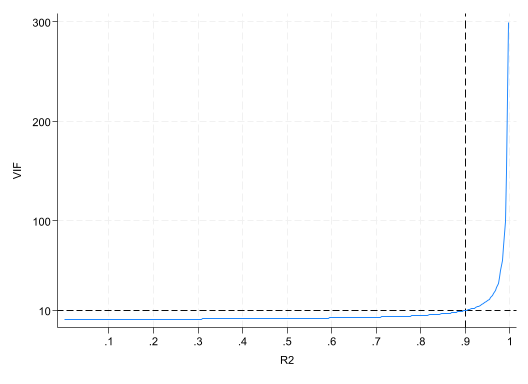

In [10]:
* 选择项xtitle(R2)指示横轴的标题为R2;
* 选择项xline(0.9,lp(dash))与yline(10,lp(dash))分别表示在横轴0.9与纵轴10的位置画一条虚线；
* 选择项xlabe1(0.1(0.1)1)表示在横轴上，从0.1至1,每隔0.1的位置给出标签；
* 选择项ylabel(10 100 200 300)则表示在纵轴上10、100、200与300的位置给出标签
twoway function VIF=1/(1-x),xtitle(R2) xline(0.9,lp(dash)) yline(10,lp(dash)) xlabel(0.1(0.1)1) ylabel(10 100 200 300)

In [11]:
* 首先，考察线性回归的VIF。
use data/grilic.dta,clear 
qui reg lnw s expr tenure smsa rns
estat vif


    Variable |       VIF       1/VIF  
-------------+----------------------
        expr |      1.12    0.893267
           s |      1.07    0.930295
      tenure |      1.06    0.944083
        smsa |      1.04    0.964256
         rns |      1.03    0.970508
-------------+----------------------
    Mean VIF |      1.06


从上表可知，最大的VIF为1.12，远小于10，故不必担心存在多重共线性。

如果在模型中引入解释变量的平方项，则容易引起多重共线性，因为$x$与$x^2$通常较相关。考虑在上述回归中加入教育年限(s)的平方项，记为s2,再进行多重共线性检验。

In [12]:
gen s2=s^2
reg lnw s s2 expr tenure smsa rns


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(6, 751)       =     68.26
       Model |  49.1549871         6  8.19249785   Prob > F        =    0.0000
    Residual |  90.1311627       751  .120014864   R-squared       =    0.3529
-------------+----------------------------------   Adj R-squared   =    0.3477
       Total |   139.28615       757  .183997556   Root MSE        =    .34643

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .0339768   .0729216     0.47   0.641    -.1091776    .1771312
          s2 |   .0024636   .0026079     0.94   0.345     -.002656    .0075832
        expr |   .0375502   .0063558     5.91   0.000     .0250729    .0500275
      tenure |   .0356461    .007743     4.60   0.

从上表可知，教育年限(s)与其平方项(s2)都很不显著。显然，二者之间可能存在多重共线性。为此，计算各变量的VIF值。

In [13]:
estat vif


    Variable |       VIF       1/VIF  
-------------+----------------------
           s |    167.07    0.005986
          s2 |    166.30    0.006013
        expr |      1.13    0.885254
      tenure |      1.06    0.944065
         rns |      1.04    0.963378
        smsa |      1.04    0.963750
-------------+----------------------
    Mean VIF |     56.27


从上表可知，变量s与s2的VIF分别达到167.07与166.30，远大于10，故存在多重共线性。进一步，将s2对s进行回归。

In [14]:
reg s2 s


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(1, 756)       >  99999.00
       Model |  2916802.81         1  2916802.81   Prob > F        =    0.0000
    Residual |  17941.0733       756  23.7315785   R-squared       =    0.9939
-------------+----------------------------------   Adj R-squared   =    0.9939
       Total |  2934743.89       757   3876.8083   Root MSE        =    4.8715

------------------------------------------------------------------------------
          s2 | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   27.81281   .0793331   350.58   0.000     27.65707    27.96854
       _cons |  -188.1622   1.078081  -174.53   0.000    -190.2785   -186.0458
------------------------------------------------------------------------------


上表显示，此回归的$R^2$高达0.9939，即变量s可以解释其平方项(s2)99%变动。这说明，s与s2所包含的信息基本相同，故会导致严重的多重共线性。

一般来说，如果回归方程中包含解释变量的多项式，则通常会导致多重共线性。一个可能的解决方法是将变量标准化，即减去均值，除以标准差：
$$
\tilde x=\frac{x-\bar x}{s_x}
$$

In [15]:
* 继续上面的例子，先计算变量s的均值与标准差，将其标准化，并记标准化变量为sd:
sum s


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           s |        758    13.40501    2.231828          9         18


In [16]:
gen sd=(s-r(mean))/r(sd)
gen sd2=sd^2
reg lnw sd sd2 expr tenure smsa rns


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(6, 751)       =     68.26
       Model |   49.154987         6  8.19249783   Prob > F        =    0.0000
    Residual |  90.1311629       751  .120014864   R-squared       =    0.3529
-------------+----------------------------------   Adj R-squared   =    0.3477
       Total |   139.28615       757  .183997556   Root MSE        =    .34643

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
          sd |   .2232421    .014444    15.46   0.000     .1948866    .2515975
         sd2 |   .0122714   .0129899     0.94   0.345    -.0132294    .0377723
        expr |   .0375502   .0063558     5.91   0.000     .0250729    .0500275
      tenure |   .0356461    .007743     4.60   0.

从上表可知，标准化的线性项(sd)在1%平上显著为正，而标准化的平方项(sd2)不显著；多重共线性似乎有所缓解。

In [17]:
* 下面，计算各变量的方差膨胀因子。
estat vif


    Variable |       VIF       1/VIF  
-------------+----------------------
          sd |      1.32    0.759911
         sd2 |      1.23    0.811990
        expr |      1.13    0.885254
      tenure |      1.06    0.944065
         rns |      1.04    0.963378
        smsa |      1.04    0.963750
-------------+----------------------
    Mean VIF |      1.14


上表显示，VIF的最大值仅为1.32，故认为基本不存在多重共线性。为了验证这一点，将sd2对sd进行回归：

In [18]:
reg sd2 sd


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(1, 756)       =    159.77
       Model |  152.821515         1  152.821515   Prob > F        =    0.0000
    Residual |  723.111439       756  .956496612   R-squared       =    0.1745
-------------+----------------------------------   Adj R-squared   =    0.1734
       Total |  875.932954       757   1.1571109   Root MSE        =    .97801

------------------------------------------------------------------------------
         sd2 | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
          sd |   .4493082   .0355462    12.64   0.000     .3795271    .5190892
       _cons |   .9986808   .0355228    28.11   0.000     .9289457    1.068416
------------------------------------------------------------------------------


此回归的$R^2$仅为0.1745，相对于s2对s回归的R2(0.9939)而言，大大下降。

由于sd2在上面的回归中不显著，下面去掉sd2，但保留sd，再次进行回归：

In [19]:
reg lnw sd expr tenure smsa rns


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(5, 752)       =     81.75
       Model |  49.0478812         5  9.80957624   Prob > F        =    0.0000
    Residual |  90.2382686       752  .119997698   R-squared       =    0.3521
-------------+----------------------------------   Adj R-squared   =    0.3478
       Total |   139.28615       757  .183997556   Root MSE        =    .34641

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
          sd |   .2290816   .0130535    17.55   0.000     .2034559    .2547073
        expr |   .0381189   .0063268     6.02   0.000     .0256986    .0505392
      tenure |   .0356146   .0077424     4.60   0.000     .0204153    .0508138
        smsa |   .1396666   .0280821     4.97   0.

注意到sd的回归系数为0.2291，似乎偏高。但由于sd为标准化的变量，故sd变化一个单位，等价于s变化一个标准差，即2.231828年。以此推算s的系数，即教育投资的年回报率应为：

In [20]:
dis .2290816/2.231828

.10264304


In [21]:
* 再次对比未将变量s标准化的回归：
reg lnw s expr tenure smsa rns


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(5, 752)       =     81.75
       Model |  49.0478814         5  9.80957628   Prob > F        =    0.0000
    Residual |  90.2382684       752  .119997697   R-squared       =    0.3521
-------------+----------------------------------   Adj R-squared   =    0.3478
       Total |   139.28615       757  .183997556   Root MSE        =    .34641

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |    .102643   .0058488    17.55   0.000     .0911611     .114125
        expr |   .0381189   .0063268     6.02   0.000     .0256986    .0505392
      tenure |   .0356146   .0077424     4.60   0.000     .0204153    .0508138
        smsa |   .1396666   .0280821     4.97   0.

对比以上两表可知，是否将变量s标准化，对于回归结果(回归系数、t统计量)没有任何实质性影响，

## 9.7 极端数据

In [22]:
use data/nerlove.dta,clear 
reg lntc lnq lnpl lnpk lnpf

(Nerlove 1963 paper)

      Source |       SS           df       MS      Number of obs   =       145
-------------+----------------------------------   F(4, 140)       =    437.90
       Model |  269.524728         4  67.3811819   Prob > F        =    0.0000
    Residual |  21.5420958       140  .153872113   R-squared       =    0.9260
-------------+----------------------------------   Adj R-squared   =    0.9239
       Total |  291.066823       144  2.02129738   Root MSE        =    .39227

------------------------------------------------------------------------------
        lntc | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |   .7209135   .0174337    41.35   0.000     .6864462    .7553808
        lnpl |   .4559645    .299802     1.52   0.131    -.1367602    1.048689
        lnpk |  -.2151476   .3398295    -0.63   0.528    -.8870089    .4567136
        lnpf |   .4258137   .

In [23]:
* 下面，将第一个观测值的产量对数(lnq)乘以100，然后再次进行回归。
* 其中，“_n”表示第n个观测值，故“_n==1”表示第1个观测值。
replace lnq=lnq*100 if _n==1
reg lntc lnq lnpl lnpk lnpf

(1 real change made)

      Source |       SS           df       MS      Number of obs   =       145
-------------+----------------------------------   F(4, 140)       =      0.92
       Model |   7.4424142         4  1.86060355   Prob > F        =    0.4551
    Residual |  283.624409       140  2.02588864   R-squared       =    0.0256
-------------+----------------------------------   Adj R-squared   =   -0.0023
       Total |  291.066823       144  2.02129738   Root MSE        =    1.4233

------------------------------------------------------------------------------
        lntc | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |   .0156026   .0218326     0.71   0.476    -.0275616    .0587668
        lnpl |   1.214014   1.093264     1.11   0.269    -.9474289    3.375456
        lnpk |  -1.096614   1.233079    -0.89   0.375    -3.534477    1.341248
        lnpf |  -.2427032   .

对比以上两表可知，人为制造极端值后，回归系数的估计值变化很大，而且所有系数都变得不显著，$R^2$也从0.926降为0.0256($\bar R^2$则变为负数)。所有这些变化都仅仅是因为在145个观测值中有一个观测值发生了变化，这正是“高影响力数据”(influential data)的含义。

In [24]:
* 下面，将此人造极端值去掉，再对比回归结果。
reg lntc lnq lnpl lnpk lnpf if _n>1


      Source |       SS           df       MS      Number of obs   =       144
-------------+----------------------------------   F(4, 139)       =    406.10
       Model |  251.560166         4  62.8900416   Prob > F        =    0.0000
    Residual |  21.5261194       139  .154864168   R-squared       =    0.9212
-------------+----------------------------------   Adj R-squared   =    0.9189
       Total |  273.086286       143  1.90969431   Root MSE        =    .39353

------------------------------------------------------------------------------
        lntc | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |   .7225462   .0182135    39.67   0.000     .6865348    .7585576
        lnpl |   .4445846   .3028466     1.47   0.144    -.1541969    1.043366
        lnpk |  -.2219834   .3415869    -0.65   0.517    -.8973614    .4533947
        lnpf |   .4311295   .1019964     4.23   0.

定义第i个观测数据对回归系数的杠杆值(leverage)为：
$$
\text{lev}_i=\mathbf{x}_i^\prime(X^\prime X)^{-1}\mathbf{x}_i
$$
其中，$\mathbf{x}_i=(1,x_{i2},\cdots,x_{iK})^\prime$包含个体i的全部解释变量，而$X=(\mathbf{x}_1 \mathbf{x}_2 \cdots \mathbf{x}_n)^\prime$为数据矩阵。

在Stata中作完回归后，计算影响力$\text{lev}_i$，的命令为：
```
predict lev,leverage
```

In [25]:
use data/nerlove.dta,clear 
qui reg lntc lnq lnpl lnpk lnpf
predict lev,leverage
sum lev

(Nerlove 1963 paper)

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
         lev |        145    .0344828    .0202164    .009924   .1177335


In [26]:
* lev的最大值是其平均值的3.41倍，似乎并不大。
dis r(max)/r(mean)

3.4142728


In [27]:
* 面来看 lev 最大的三个数值：
gsort -lev
list lev in 1/3


     +----------+
     |      lev |
     |----------|
  1. | .1177335 |
  2. | .1001472 |
  3. | .0983759 |
     +----------+


In [28]:
* 为了演示目的，再次人为制造极端数据，将第一个观测值的产量对数(lnq)乘以100，然后计算lev。
replace lnq=lnq*100 if _n==1
qui reg lntc lnq lnpl lnpk lnpf
predict lev1,lev
sum lev1

(1 real change made)

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        lev1 |        145    .0344828    .0807897   .0083048   .9801415


In [29]:
* 结果显示，lev的最大值是其平均值的28.42倍，故存在高影响力的极端观测值。
dis r(max)/r(mean)

28.424102


## 9.9 经济结构变动的检验

对于时间序列而言，模型系数的稳定性(stability)是很重要的问题。如果存在结构变动(structural break)，但未加考虑，也是一种模型设定误差。

下面以数据集consumption.dta为例，考察中国的消费函数是否在1992年发生了结构变化。先看一下中国1978—2013年以当年价格计的“居民人均消费”(c)与“人均国内生产总值”(y)的年度(year)时间趋势图

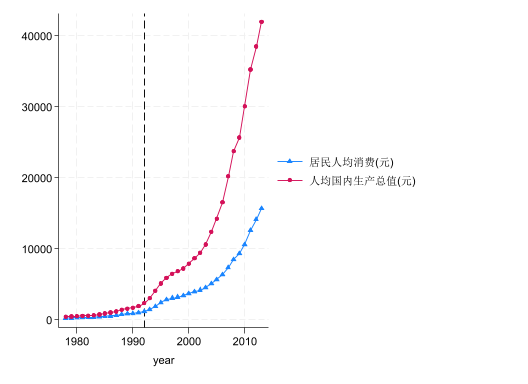

In [30]:
use data/consumption.dta,clear
* 选择项“xlabel(1980(10)2010)”表示在横轴(即X轴)1980—2010年之间，每隔10年做个标注(label);
* 选择项“xline(1992)”表示在横轴1992年的位置画一条直线。
twoway connect c y year,msymbol(circle) msymbol(triangle) xlabel(1980(10)2010) xline(1992)

考察一个简单的消费函数：
$$
c_t=\alpha+\beta y_t+\epsilon_t
$$

首先，使用传统的F检验来检验消费函数是否在1992年发生结构变动。分别对整个样本、1992年之前及之后的子样本进行回归，以获得其残差平方和：

In [31]:
reg c y


      Source |       SS           df       MS      Number of obs   =        36
-------------+----------------------------------   F(1, 34)        =   7139.56
       Model |   617812224         1   617812224   Prob > F        =    0.0000
    Residual |  2942143.12        34  86533.6213   R-squared       =    0.9953
-------------+----------------------------------   Adj R-squared   =    0.9951
       Total |   620754367        35  17735839.1   Root MSE        =    294.17

------------------------------------------------------------------------------
           c | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           y |   .3572642   .0042282    84.50   0.000     .3486715    .3658569
       _cons |   339.0701   63.83305     5.31   0.000     209.3458    468.7945
------------------------------------------------------------------------------


In [32]:
* “scalar”表示标量，即将此回归的残差平方和(e(rss))记为标量ssr。
scalar ssr=e(rss)
* 下面，对1992年之前的子样本进行回归。
reg c y if year<1992


      Source |       SS           df       MS      Number of obs   =        14
-------------+----------------------------------   F(1, 12)        =   4344.64
       Model |  829125.648         1  829125.648   Prob > F        =    0.0000
    Residual |  2290.06599        12  190.838833   R-squared       =    0.9972
-------------+----------------------------------   Adj R-squared   =    0.9970
       Total |  831415.714        13  63955.0549   Root MSE        =    13.814

------------------------------------------------------------------------------
           c | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           y |   .4996452   .0075803    65.91   0.000     .4831292    .5161612
       _cons |   12.89123   7.908212     1.63   0.129    -4.339283    30.12174
------------------------------------------------------------------------------


In [33]:
* 将1992年之前的子样本回归的残差平方和记为ssr
scalar ssr1=e(rss)
* 然后，对1992年及之后的子样本进行回归。
reg c y if year>=1992


      Source |       SS           df       MS      Number of obs   =        22
-------------+----------------------------------   F(1, 20)        =   4889.80
       Model |   366038781         1   366038781   Prob > F        =    0.0000
    Residual |     1497151        20  74857.5501   R-squared       =    0.9959
-------------+----------------------------------   Adj R-squared   =    0.9957
       Total |   367535932        21    17501711   Root MSE        =     273.6

------------------------------------------------------------------------------
           c | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           y |   .3444589    .004926    69.93   0.000     .3341836    .3547343
       _cons |   658.1088   95.04293     6.92   0.000     459.8527    856.3648
------------------------------------------------------------------------------


In [34]:
* 令将1992年及之后的子样本回归的残差平方和记为ssr2
scalar ssr2=e(rss)
* 由于n=36,K=2,n-2K=32,故可计算F统计量如下：
di ((ssr-ssr1-ssr2)/2)/((ssr1+ssr2)/32)

15.394558


In [35]:
* 其次，使用虚拟变量法进行结构变动的检验。
* 生成虚拟变量d(对于1992年及以后，d=1；反之，d=0)；
gen d=(year>1991)
* 以及虚拟变量d与人均收入y的互动项yd:
gen yd=y*d
* 引入d与yd,进行全样本 OLS 回归：
reg c y d yd


      Source |       SS           df       MS      Number of obs   =        36
-------------+----------------------------------   F(3, 32)        =   4405.23
       Model |   619254926         3   206418309   Prob > F        =    0.0000
    Residual |  1499441.07        32  46857.5333   R-squared       =    0.9976
-------------+----------------------------------   Adj R-squared   =    0.9974
       Total |   620754367        35  17735839.1   Root MSE        =    216.47

------------------------------------------------------------------------------
           c | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           y |   .4996452   .1187794     4.21   0.000     .2576994     .741591
           d |   645.2175   144.9484     4.45   0.000     349.9673    940.4678
          yd |  -.1551863   .1188434    -1.31   0.201    -.3972623    .0868897
       _cons |   12.89123   123.9181     0.10   0.

In [36]:
* 然后检验d与yd的联合显著性：
test d yd


 ( 1)  d = 0
 ( 2)  yd = 0

       F(  2,    32) =   15.39
            Prob > F =    0.0000


上表显示，使用虚拟变量法所得F统计量也为15.39，与传统的F检验完全相同。该检验的p值为0.0000，故可在1%平上强烈拒绝“无结构变动”的原假设。

然而，上述结构变化检验仅在球形扰动项(同方差、无自相关)的情况下才成立。为此，下面进行异方差与自相关的检验：

In [37]:
qui reg c y
estat imtest,white


White's test
H0: Homoskedasticity
Ha: Unrestricted heteroskedasticity

    chi2(2) =   6.31
Prob > chi2 = 0.0427

Cameron & Trivedi's decomposition of IM-test

--------------------------------------------------
              Source |       chi2     df         p
---------------------+----------------------------
  Heteroskedasticity |       6.31      2    0.0427
            Skewness |       4.11      1    0.0425
            Kurtosis |       4.76      1    0.0291
---------------------+----------------------------
               Total |      15.19      4    0.0043
--------------------------------------------------


上表显示，怀特检验的结果可在5%水平上拒绝“同方差”的原假设。

In [38]:
* 为了进行自相关的 BG 检验，首先设定变量 year 为时间变量。
tsset year


Time variable: year, 1978 to 2013
        Delta: 1 unit


In [39]:
estat bgodfrey


Breusch–Godfrey LM test for autocorrelation
---------------------------------------------------------------------------
    lags(p)  |          chi2               df                 Prob > chi2
-------------+-------------------------------------------------------------
       1     |         28.109               1                   0.0000
---------------------------------------------------------------------------
                        H0: no serial correlation


上表显示，可在1%平上强烈拒绝“无自相关”的原假设。

总之，此模型的扰动项存在异方差与自相关。故应使用异方差自相关稳健的标准误，通过虚拟变量法检验结构变动。

In [40]:
* 首先，计算 HAC 标准误的截断参数。
dis 36^(1/4)

2.4494897


In [41]:
* 故应将截断参数设为3。下面进行Newey-West回归。
newey c y d yd,lag(3)


Regression with Newey–West standard errors      Number of obs     =         36
Maximum lag = 3                                 F(  3,        32) =    2455.09
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
           c | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           y |   .4996452   .0099228    50.35   0.000     .4794332    .5198573
           d |   645.2175    139.943     4.61   0.000     360.1629    930.2721
          yd |  -.1551863    .013774   -11.27   0.000    -.1832431   -.1271295
       _cons |   12.89123   10.16563     1.27   0.214    -7.815475    33.59793
------------------------------------------------------------------------------


In [42]:
* 然后，检验虚拟变量d及其互动项yd的联合显著性。
test d yd


 ( 1)  d = 0
 ( 2)  yd = 0

       F(  2,    32) =   73.05
            Prob > F =    0.0000


该检验的p值为0.0000，故可在1%平上强烈拒绝“无结构变动”的原假设，即认为中国的消费函数在1992年发生了结构变动。

## 9.10 缺失数据与线性插值

在数据缺失不严重的情况下，为保持样本容量，可采用线性插值(linear interpolation)的方法来补上缺失数据。

线性插值的Stata命令为
```
ipolateyx,gen(newvar)
```
- 其中，“ipolate”表示interpolate，即将变量y对变量x进行线性插值，并将插值的结果记为新变量newvar。

In [43]:
use data/consumption.dta,clear
* 为了演示目的，假设1980年、1990年、2000年及2010年的人均GDP数据缺失。
* 首先，生成缺失这些年份数据的人均GDP变量，并记为yl。
gen y1=y
* 缺失的观测值在Stata中以“.”来表示
replace y1=. if year==1980 | year==1990 | year==2000 | year==2010

(4 real changes made, 4 to missing)


In [44]:
* 下面，直接用yl对year进行线性插值，并将结果记为y2。
ipolate y1 year,gen(y2)

In [45]:
* 由于人均GDP有指数增长趋势，故更好的做法是，先对y1取对数，进行线性插值，再取反对数，并将结果记为y3。
gen lny1=log(y1)
ipolate lny1 year,gen(lny3)
gen y3=exp(lny3)

(4 missing values generated)


In [46]:
* 下面，对比这两种方法的效果。
list year y y2 y3 if year==1980 | year==1990 | year==2000 | year==2010


     +---------------------------------------+
     | year         y          y2         y3 |
     |---------------------------------------|
  3. | 1980    463.25     455.705   454.2445 |
 13. | 1990      1644     1705.88   1695.613 |
 23. | 2000   7857.68    7890.105   7856.112 |
 33. | 2010   30015.1   30402.659   30022.13 |
     +---------------------------------------+


从上表可知，直接插值的结果y2倾向于高估真实值y，而且整体估计效果不如先取对数再插值的结果y3(1980年的结果是个例外)。